# Task 32: Clustering with KMeans

Clustering is an unsupervised learning technique used to group similar data points into clusters. The KMeans algorithm is one of the most popular clustering methods that partitions a dataset into distinct groups based on feature similarities. Each cluster is characterized by its centroid, and data points are assigned to the cluster whose centroid is nearest is.

## Steps to Follow:

1. **Data Preprocessing**:
   - Load and preprocess the dataset to make it suitable for clustering.

2. **Determine the Optimal Number of Clusters**:
   - Use the Elbow Method to identify the optimal number of clusters by plotting the within-cluster sum of squares (WCSS) against the number of clusters and finding the 'elbow point.'

3. **Apply KMeans Clustering**:
   - Implement the KMeans algorithm using the optimal number of clusters.

4. **Visualize the Clusters**:
   - Create scatter plots to visualize the clusters and inter l Customers dataset.


In [4]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# Load the Breast Cancer dataset
data = load_breast_cancer()
features = pd.DataFrame(data.data, columns=data.feature_names)

# Display the first few rows of the dataset
print("Dataset Overview:")
print(features.head())

Dataset Overview:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimet

In [6]:
# Select relevant features for clustering (we'll use the first two features for visualization)
features_selected = features.iloc[:, :2]



In [7]:
# Standardize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_selected)


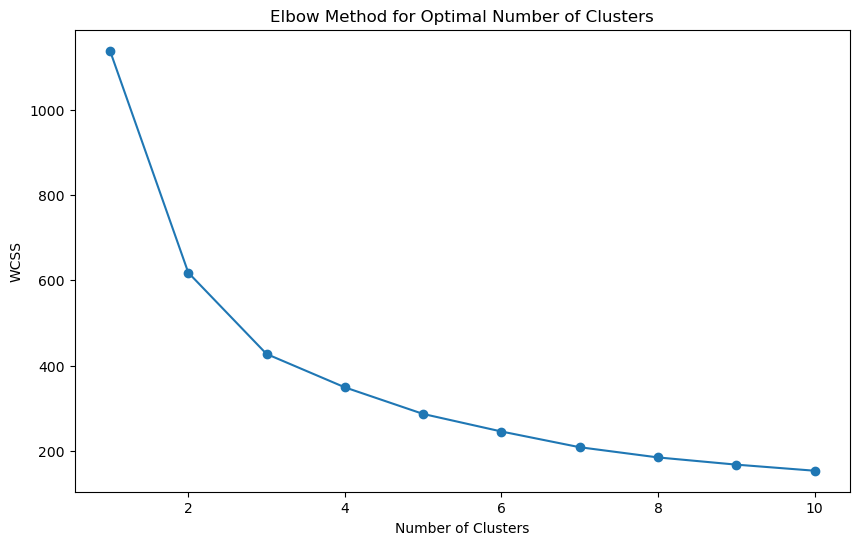

C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


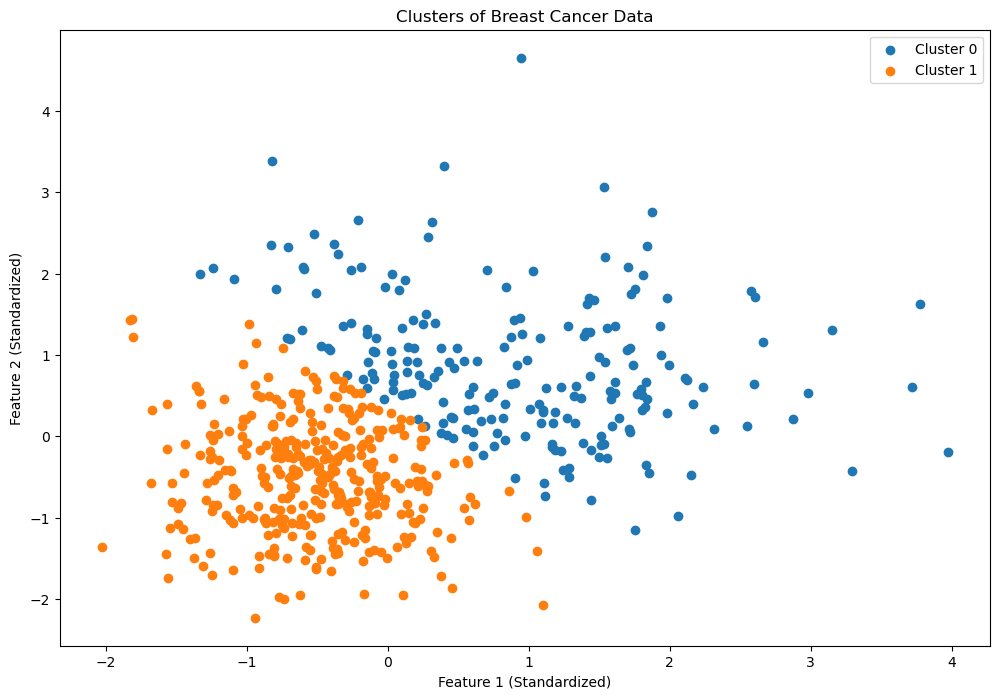

In [10]:

# Plot the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Apply KMeans with the optimal number of clusters
optimal_clusters = 2  # Assuming 2 is the optimal number found from the Elbow Method
kmeans = KMeans(n_clusters=optimal_clusters, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(features_scaled)

# Add the cluster information to the dataset
features['Cluster'] = clusters

# Visualize the clusters
plt.figure(figsize=(12, 8))
for i in range(optimal_clusters):
    plt.scatter(features_scaled[features['Cluster'] == i, 0], features_scaled[features['Cluster'] == i, 1], label=f'Cluster {i}')
plt.title('Clusters of Breast Cancer Data')
plt.xlabel('Feature 1 (Standardized)')
plt.ylabel('Feature 2 (Standardized)')
plt.legend()
plt.show()